In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from TestEnv import HydroElectric_Test

df = pd.read_csv("history.csv")
env = HydroElectric_Test("validate.xlsx")
a = df["action"].to_numpy(float)

df["action_mwh"] = np.where(
    a >= 0,  a * env.volume_to_MWh / env.pump_efficiency,  #pump +
            a * env.volume_to_MWh * env.flow_efficiency    #generative -
)
df["t_day"] = df["t"] / 24.0

#Reservoir level as a fraction of capacity (vol/max_vol)
df["vol_frac"] = (df["volume"] / env.max_volume).clip(0, 1)

cmap = LinearSegmentedColormap.from_list("bgr", ["#2166ac", "#bdbdbd", "#b2182b"], N=256)

#ormalization around 0 so equal magnitudes have equal color intensity
max_abs = float(np.abs(df["action_mwh"]).max())
norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)

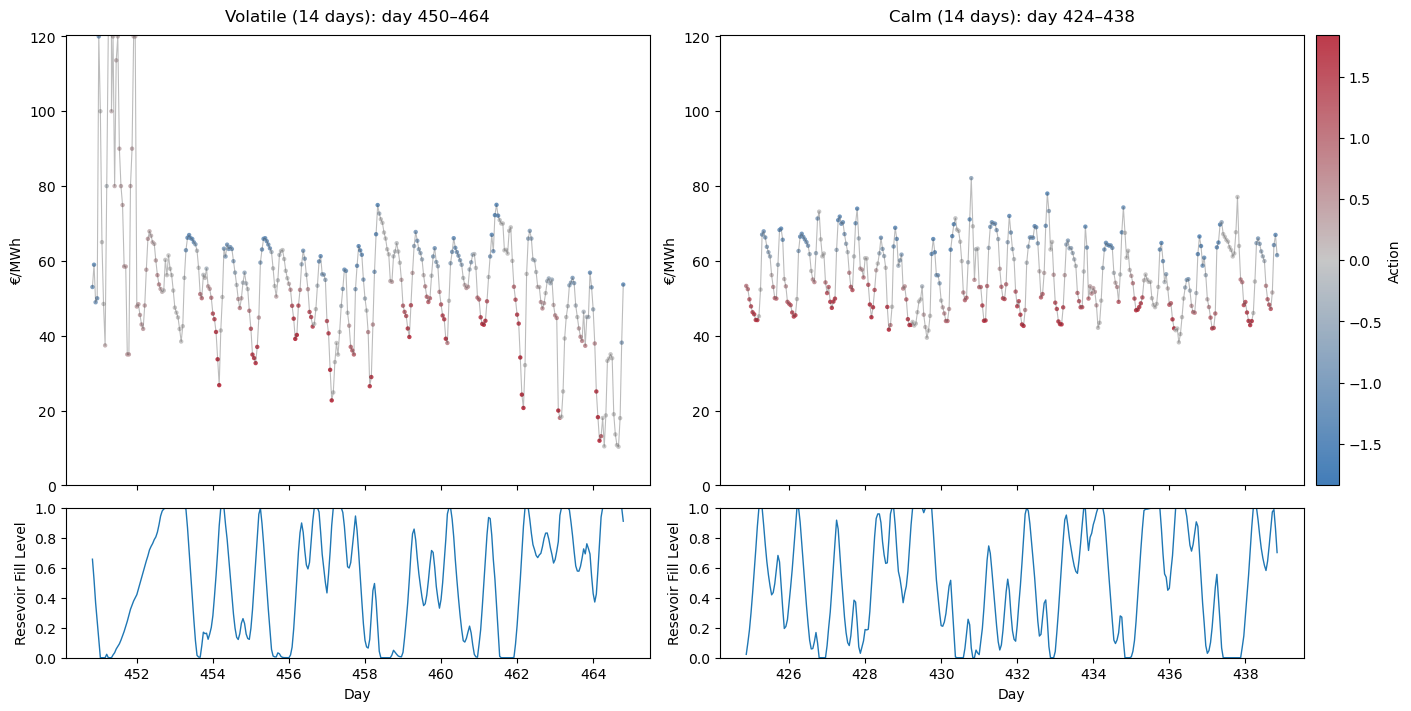

In [178]:
#window length in hours (14 days)
w = 14 * 24

#rolling volatility measure (std) over the window
roll = df["price"].rolling(w).std().dropna()

#indices of most volatile and most calm endpoints
i_vol, i_cal = int(roll.idxmax()), int(roll.idxmin())

df_vol = df.iloc[i_vol - w + 1 : i_vol + 1]
df_cal = df.iloc[i_cal - w + 1 : i_cal + 1]
ymax = float(max(df_vol["price"].quantile(0.995), df_cal["price"].quantile(0.995)))

fig, ax = plt.subplots(
    2, 2, figsize=(14, 7),
    sharex="col",
    constrained_layout=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

ax_p_vol, ax_p_cal = ax[0, 0], ax[0, 1]
ax_v_vol, ax_v_cal = ax[1, 0], ax[1, 1]

for axp, axv, dwin, title in [
    (ax_p_vol, ax_v_vol, df_vol, f"Volatile (14 days): day {int(df_vol['t'].min()//24)}–{int(df_vol['t'].max()//24)}"),
    (ax_p_cal, ax_v_cal, df_cal, f"Calm (14 days): day {int(df_cal['t'].min()//24)}–{int(df_cal['t'].max()//24)}"),
]:
    axp.plot(dwin["t_day"], dwin["price"], linewidth=0.8, alpha=0.35, color="0.25")

    sc = axp.scatter(
        dwin["t_day"], dwin["price"],
        c=dwin["action_mwh"], cmap=cmap, norm=norm,
        s=10, alpha=0.85, linewidth=0, rasterized=True
    )

    axp.set_title(title, pad=10)
    axp.set_ylim(0, ymax)
    axp.set_ylabel("€/MWh")

    #volume fraction 
    axv.plot(dwin["t_day"], dwin["vol_frac"], linewidth=1.0)
    axv.set_ylim(0, 1)
    axv.set_ylabel("Resevoir Fill Level")
    axv.set_xlabel("Day")

fig.colorbar(sc, ax=[ax_p_vol, ax_p_cal], pad=0.01, label="Action")
plt.show()

Created these to compare the operation over the most volatile and most calm 14-day periods with top row showing the price trajectory. The bottom row shows the corresponding reservoir fill fraction so you can see how storage constraints shape feasible actions over time. 

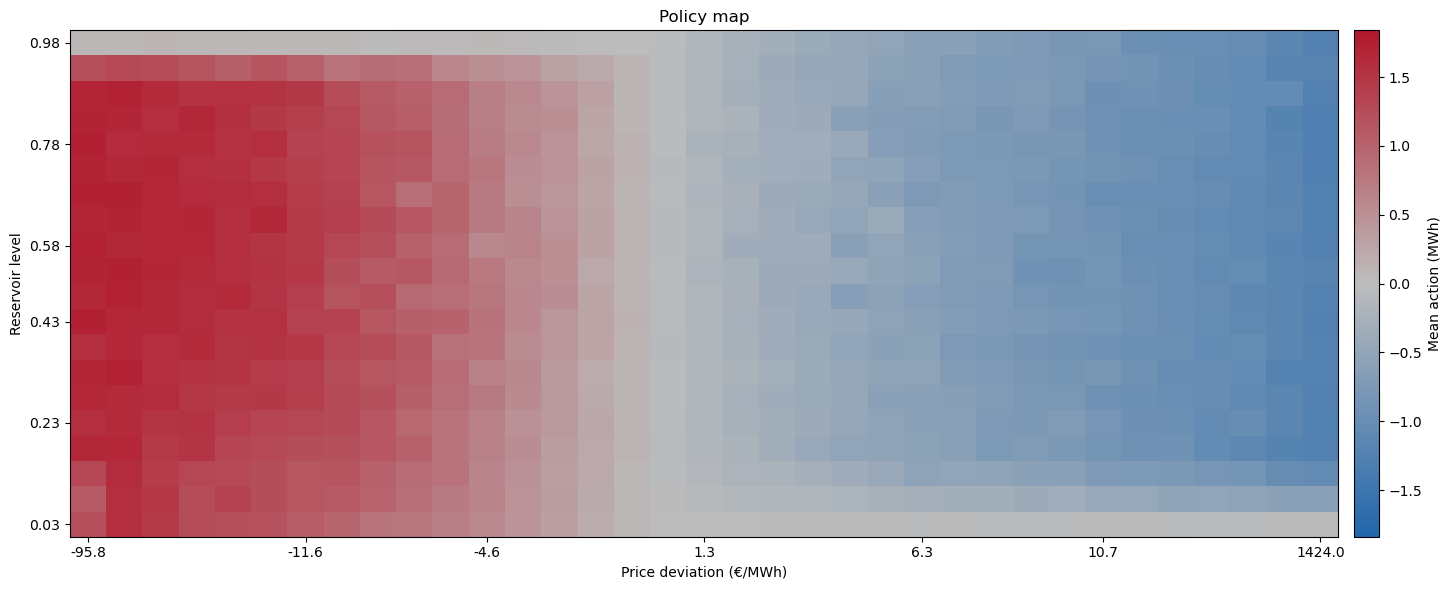

In [182]:
#Policy map: mean action vs (price deviation, reservoir level)

#Price deviation (price minus rolling 24h mean) 
df["price_dev"] = df["price"] - df["price"].rolling(24, min_periods=24).mean()
d = df.dropna(subset=["price_dev"]).copy()

#Bin price deviation into quantiles (balanced counts per bin) and store the bin edges for labeling
price_bin, price_edges = pd.qcut(d["price_dev"], q=35, retbins=True, duplicates="drop")

#Bin reservoir level uniformly from 0 to 1
vol_edges = np.linspace(0, 1, 21)
vol_bin = pd.cut(d["vol_frac"], bins=vol_edges, include_lowest=True)

#Mean action in each (vol_bin, price_bin)
policy = d.pivot_table(index=vol_bin, columns=price_bin, values="action_mwh", aggfunc="mean", observed=False)

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(policy.values, aspect="auto", origin="lower", cmap=cmap, norm=norm)

ax.set_title("Policy map")
ax.set_xlabel("Price deviation (€/MWh)")
ax.set_ylabel("Reservoir level")

nx, ny = policy.shape[1], policy.shape[0]

# x ticks are midpoints of price-dev bins (in €/MWh)
xt = np.linspace(0, nx - 1, 7).round().astype(int)
ax.set_xticks(xt)
ax.set_xticklabels([f"{0.5*(price_edges[i] + price_edges[i+1]):.1f}" for i in xt])

# y ticks are midpoints of vol_frac bins
yt = np.linspace(0, ny - 1, 6).round().astype(int)
ax.set_yticks(yt)
ax.set_yticklabels([f"{0.5*(vol_edges[i] + vol_edges[i+1]):.2f}" for i in yt])

fig.colorbar(im, ax=ax, pad=0.01, label="Mean action (MWh)")
plt.tight_layout()
plt.show()

Heatmap summarizes what the action tends to do as a function of two context variables 1. is price deviation from the 24-hour rolling mean 2. is reservoir fill level vol_frac. Colors show the average action in grid MWh in each bin. Actions shift from pumping at low prices to generating at high prices and magnitude is constrained by how full the reservoir is.